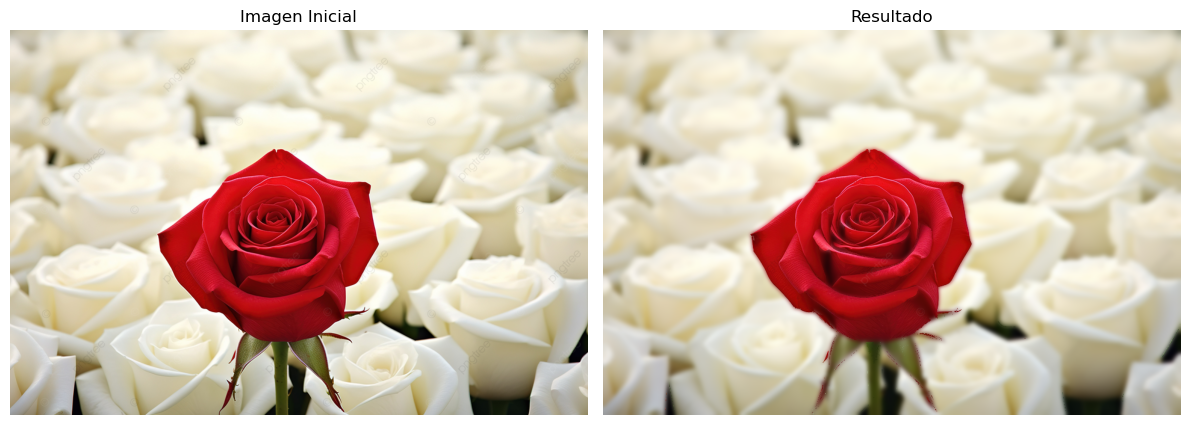

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('rosa.png')
original = img.copy()

blurred = cv2.GaussianBlur(img, (21, 21), 0)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

mask_red1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
mask_red2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
mask_red = cv2.bitwise_or(mask_red1, mask_red2)

mask_green = cv2.inRange(hsv, np.array([36, 50, 50]), np.array([70, 255, 255]))

mask_no_blur = cv2.bitwise_or(mask_red, mask_green)
mask_no_blur = cv2.bitwise_not(mask_no_blur)

blur_zones = cv2.bitwise_and(blurred, blurred, mask=mask_no_blur)
no_blur_zones = cv2.bitwise_and(original, original, mask=cv2.bitwise_not(mask_no_blur))
result = cv2.add(blur_zones, no_blur_zones)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagen Inicial')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1].set_title('Resultado')
axes[1].axis('off')
plt.tight_layout()
plt.show()


2.- Usando la imagen imagen1.jpg obtiene el siguiente resultado (utiliza máscaras de convolución)

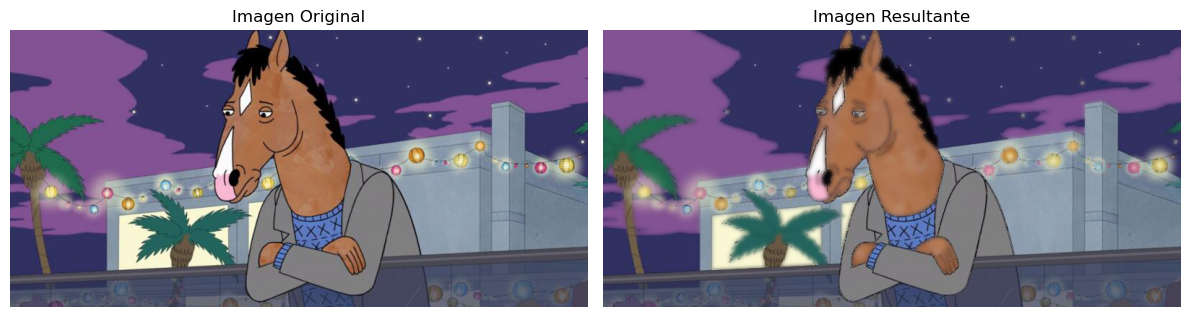

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg')
original = img.copy()

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

mask_brown = cv2.inRange(hsv, np.array([0, 50, 50]), np.array([30, 150, 150]))
mask_gray = cv2.inRange(hsv, np.array([0, 0, 50]), np.array([180, 50, 200]))
mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 50, 50]))
mask_blue = cv2.inRange(hsv, np.array([100, 50, 50]), np.array([130, 255, 255]))

mask_keep = cv2.bitwise_or(cv2.bitwise_or(mask_brown, mask_gray), cv2.bitwise_or(mask_black, mask_blue))

# Aplicar máscara Gaussian Blur
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
blur = cv2.GaussianBlur(img, (15, 15), 0)
mask_blur = cv2.bitwise_not(mask_keep)

blur_zones = cv2.bitwise_and(blur, blur, mask=mask_blur)
sharp_zones = cv2.bitwise_and(original, original, mask=mask_keep)
result = cv2.add(blur_zones, sharp_zones)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagen Original')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1].set_title('Imagen Resultante')
axes[1].axis('off')
plt.tight_layout()
plt.show()


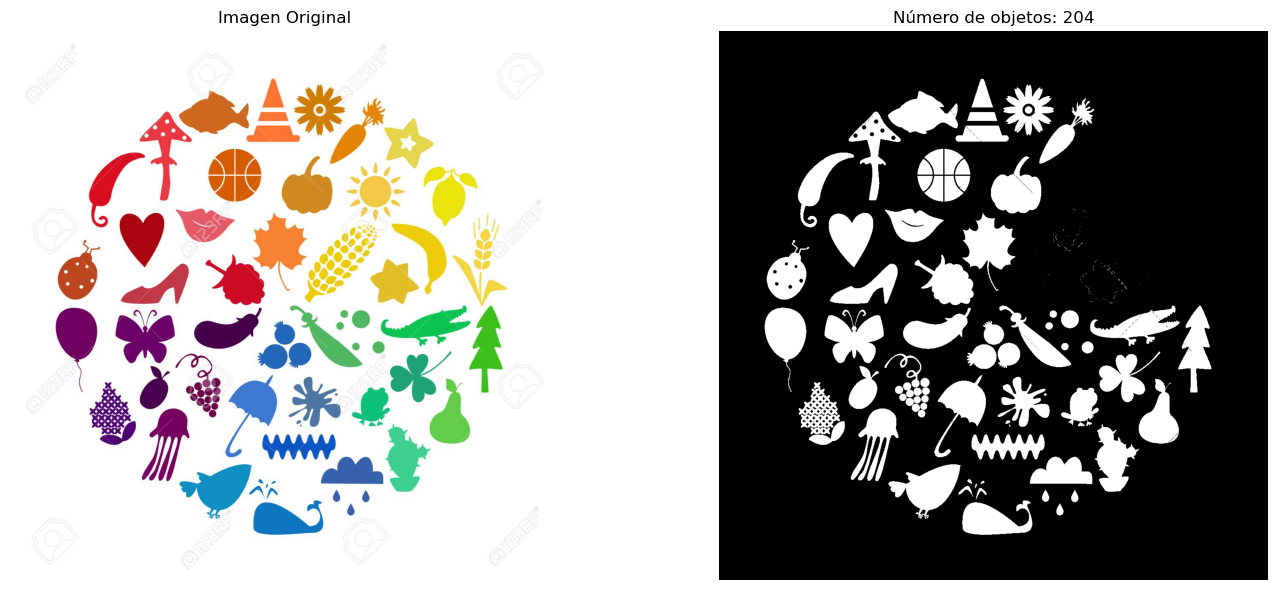

In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binario = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Aplicar
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, 1))
    limpio = cv2.morphologyEx(binario, cv2.MORPH_CLOSE, kernel, iterations=1)
    limpio = cv2.dilate(limpio, kernel, iterations=2)
    limpio = cv2.erode(limpio, kernel, iterations=1)
    
    # Componentes
    num_labels, labels = cv2.connectedComponents(limpio)
    num_obj = num_labels + 1
    return num_obj, limpio

elementos = cv2.imread('Elementos.jpg')
conteo = contar_elementos(elementos)

# Convertir a RGB
elementos_rgb = cv2.cvtColor(elementos, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(elementos_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(conteo[1], cmap='gray')
plt.title(f'Número de objetos: {conteo[0]}')
plt.axis('off')

plt.tight_layout()
plt.show()

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

5.- Según la imagen puntos.png y pato.jpg obtiene el siguiente resultado

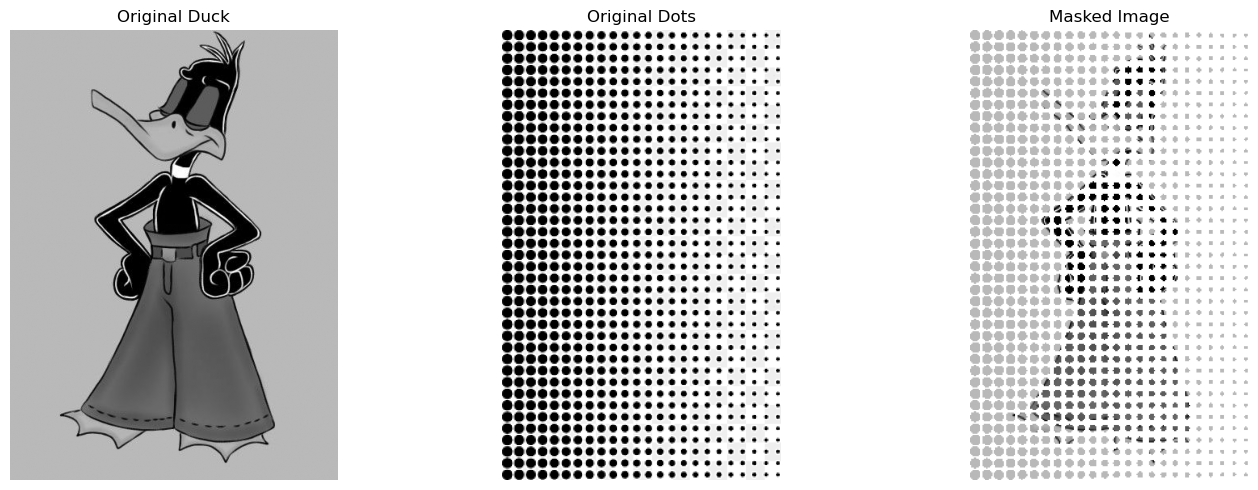

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

pato = cv2.imread('pato.jpg')
puntos = cv2.imread('puntos.png')

puntos_gray = cv2.cvtColor(puntos, cv2.COLOR_BGR2GRAY)
_, puntos_mask = cv2.threshold(puntos_gray, 127, 255, cv2.THRESH_BINARY)

pato_resized = cv2.resize(pato, (puntos.shape[1], puntos.shape[0]))

puntos_mask_inv = cv2.bitwise_not(puntos_mask)

result = cv2.bitwise_and(pato_resized, pato_resized, mask=puntos_mask_inv)

white_bg = np.ones_like(pato_resized, dtype=np.uint8) * 255
result = cv2.add(result, cv2.bitwise_and(white_bg, white_bg, mask=puntos_mask))

result_gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

pato_gray = cv2.cvtColor(pato, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(pato_gray, cmap='gray')
axes[0].set_title('Original Duck')
axes[0].axis('off')

axes[1].imshow(puntos_gray, cmap='gray')
axes[1].set_title('Original Dots')
axes[1].axis('off')

axes[2].imshow(result_gray, cmap='gray')
axes[2].set_title('Masked Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()
